# Disease Prioritization Framework

**User Story 3**: Multi-Criteria Disease Burden Prioritization

**Objective**: Develop a transparent, evidence-based framework for ranking diseases using weighted multi-criteria scoring to support MOH resource allocation decisions.

**Author**: MOH Data Analytics Team  
**Created**: 2026-02-12  
**Last Updated**: 2026-02-12

## Table of Contents
1. [Setup & Data Loading](#setup)
2. [Data Validation](#validation)
3. [Base Case Prioritization](#base-case)
4. [Tier Assignment](#tiers)
5. [Sensitivity Analysis](#sensitivity)
6. [Visualizations](#visualizations)
7. [Results Export](#export)
8. [Summary & Insights](#summary)

## 1. Setup & Data Loading <a id='setup'></a>

Import required libraries and configure environment.

In [10]:
# Standard library imports
import logging
import sys
from datetime import datetime
from pathlib import Path

# Third-party imports
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Project imports
sys.path.append(str(Path.cwd().parent.parent))
from src.config import load_prioritization_config
from src.analysis.prioritization import (
    validate_burden_metrics_input,
    calculate_composite_score,
    assign_tiers,
    rank_diseases,
    sensitivity_analysis,
    calculate_rank_correlation,
    identify_consensus_priorities
)

# Configure visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)

print("✓ Libraries imported successfully")
print(f"Execution date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Libraries imported successfully
Execution date: 2026-02-12 10:33:18


In [11]:
# Load configuration
try:
    config = load_prioritization_config('../../config/prioritization.yml')
    logger.info("Configuration loaded successfully")
    
    # Display configuration
    print("\n=== Base Case Configuration ===")
    print("Weights:")
    for criterion, weight in config['base_case']['weights'].items():
        print(f"  {criterion}: {weight*100:.0f}%")
    
    print("\nTier Thresholds:")
    print(f"  High Priority: > {config['base_case']['tier_thresholds']['high']}")
    print(f"  Medium Priority: {config['base_case']['tier_thresholds']['medium']}-{config['base_case']['tier_thresholds']['high']}")
    print(f"  Low Priority: < {config['base_case']['tier_thresholds']['medium']}")
    
    print(f"\nSensitivity Scenarios: {list(config['scenarios'].keys())}")
    
except FileNotFoundError as e:
    logger.error(f"Configuration file not found: {e}")
    raise
except Exception as e:
    logger.error(f"Error loading configuration: {e}")
    raise

2026-02-12 10:33:18,727 - src.config - INFO - Successfully loaded configuration from ../../config/prioritization.yml
2026-02-12 10:33:18,727 - src.config - INFO - Configuration validated successfully: 3 scenarios loaded
2026-02-12 10:33:18,728 - __main__ - INFO - Configuration loaded successfully

=== Base Case Configuration ===
Weights:
  volume: 40%
  trend: 25%
  outbreak: 20%
  variability: 15%

Tier Thresholds:
  High Priority: > 70.0
  Medium Priority: 40.0-70.0
  Low Priority: < 40.0

Sensitivity Scenarios: ['volume_focused', 'emerging_threat_focused', 'stability_focused']


In [12]:
# Load burden metrics data
try:
    data_path = '../../data/4_processed/disease_burden_metrics.csv'
    df = pl.read_csv(data_path)
    logger.info(f"Loaded {len(df)} diseases from {data_path}")
    
    print(f"\n=== Data Summary ===")
    print(f"Total diseases: {len(df)}")
    print(f"Diseases with sufficient data: {df.filter(pl.col('sufficient_data') == True).shape[0]}")
    print(f"\nDataFrame shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")
    
    # Display first few rows
    print("\nFirst 3 diseases:")
    display(df.select(['disease_name', 'total_cases', 'annual_avg_cases', 'sufficient_data']).head(3))
    
except FileNotFoundError:
    logger.error(f"Data file not found: {data_path}")
    logger.error("Please run User Story 2 notebook first to generate burden metrics.")
    raise
except Exception as e:
    logger.error(f"Error loading data: {e}")
    raise

2026-02-12 10:33:18,740 - __main__ - INFO - Loaded 44 diseases from ../../data/4_processed/disease_burden_metrics.csv

=== Data Summary ===
Total diseases: 44
Diseases with sufficient data: 27

DataFrame shape: (44, 37)
Columns: 37

First 3 diseases:


disease_name,total_cases,annual_avg_cases,sufficient_data
str,i64,f64,bool
"""Dengue Fever""",126642,14071.333333,true
"""Hand, Foot and…",235409,26156.555556,true
"""Dengue Haemorr…",366,40.666667,true


## 2. Data Validation <a id='validation'></a>

Validate data quality and filter to diseases with sufficient data for reliable prioritization.

In [13]:
# Validate input data structure
try:
    validate_burden_metrics_input(df)
    logger.info("✓ Input validation passed")
except Exception as e:
    logger.error(f"Input validation failed: {e}")
    raise

# Filter to diseases with sufficient data
df_valid = df.filter(pl.col('sufficient_data') == True)
n_excluded = len(df) - len(df_valid)
logger.info(f"Filtered to {len(df_valid)} diseases with sufficient data ({n_excluded} excluded)")

print(f"\n=== Data Quality Summary ===")
print(f"Valid diseases for prioritization: {len(df_valid)}")
print(f"Excluded diseases (insufficient data): {n_excluded}")

if n_excluded > 0:
    excluded_diseases = df.filter(pl.col('sufficient_data') == False)['disease_name'].to_list()
    print(f"\nExcluded diseases: {', '.join(excluded_diseases[:5])}{'...' if len(excluded_diseases) > 5 else ''}")

2026-02-12 10:33:18,759 - src.analysis.prioritization - WARNING - Score column 'coefficient_variation_score' out of range [0, 100]: [0.0, 100.00000000000001]
2026-02-12 10:33:18,761 - src.analysis.prioritization - WARNING - Score column 'variability_score' out of range [0, 100]: [0.0, 100.00000000000001]
2026-02-12 10:33:18,762 - src.analysis.prioritization - INFO - Validated 44 diseases with 13 score columns
2026-02-12 10:33:18,763 - __main__ - INFO - ✓ Input validation passed
2026-02-12 10:33:18,765 - __main__ - INFO - Filtered to 27 diseases with sufficient data (17 excluded)

=== Data Quality Summary ===
Valid diseases for prioritization: 27
Excluded diseases (insufficient data): 17

Excluded diseases: Haemophilus influenzae type b, Avian Influenza, Zika Virus Infection, Diphtheria, Tetanus...


In [14]:
# Check score column ranges
score_cols = ['total_cases_score', 'annual_avg_cases_score', 'cagr_score', 
              'outbreak_score', 'coefficient_variation_score']

print("\n=== Score Column Ranges ===")
for col in score_cols:
    min_val = df_valid[col].min()
    max_val = df_valid[col].max()
    mean_val = df_valid[col].mean()
    print(f"{col:35s}: [{min_val:6.2f}, {max_val:6.2f}] (mean: {mean_val:6.2f})")
    
    if min_val < 0 or max_val > 100:
        logger.warning(f"{col} out of expected range [0, 100]")


=== Score Column Ranges ===
total_cases_score                  : [  0.03, 100.00] (mean:   6.22)
annual_avg_cases_score             : [  0.03, 100.00] (mean:   6.22)
cagr_score                         : [  0.00, 100.00] (mean:  63.71)
outbreak_score                     : [  0.00,  50.00] (mean:  17.99)
coefficient_variation_score        : [  0.00,  14.05] (mean:   4.68)


## 3. Base Case Prioritization <a id='base-case'></a>

Calculate composite burden scores using base case weighting scheme:
- Volume: 40%
- Trend: 25%
- Outbreak: 20%
- Variability: 15%

In [15]:
# Calculate composite scores with base case weights
base_weights = config['base_case']['weights']

try:
    df_scored = calculate_composite_score(df_valid, base_weights)
    logger.info(f"Calculated composite scores for {len(df_scored)} diseases")
    
    # Display composite score statistics
    print("\n=== Composite Score Statistics ===")
    print(f"Mean: {df_scored['composite_score'].mean():.2f}")
    print(f"Median: {df_scored['composite_score'].median():.2f}")
    print(f"Std Dev: {df_scored['composite_score'].std():.2f}")
    print(f"Min: {df_scored['composite_score'].min():.2f}")
    print(f"Max: {df_scored['composite_score'].max():.2f}")
    
except Exception as e:
    logger.error(f"Error calculating composite scores: {e}")
    raise

2026-02-12 10:33:18,793 - src.analysis.prioritization - INFO - Calculated composite scores with weights: {'volume': 0.4, 'trend': 0.25, 'outbreak': 0.2, 'variability': 0.15}
2026-02-12 10:33:18,795 - __main__ - INFO - Calculated composite scores for 27 diseases

=== Composite Score Statistics ===
Mean: 24.80
Median: 22.85
Std Dev: 9.98
Min: 4.95
Max: 49.39


In [16]:
# Display score breakdown for top 10 diseases
df_preview = df_scored.select([
    'disease_name',
    'volume_criterion',
    'trend_criterion', 
    'outbreak_criterion',
    'variability_criterion',
    'composite_score'
]).sort('composite_score', descending=True).head(10)

print("\n=== Top 10 Diseases by Composite Score ===")
print("(Before ranking and tier assignment)")
display(df_preview)


=== Top 10 Diseases by Composite Score ===
(Before ranking and tier assignment)


disease_name,volume_criterion,trend_criterion,outbreak_criterion,variability_criterion,composite_score
str,f64,f64,f64,f64,f64
"""Dengue Fever""",53.796584,98.711133,13.501122,3.275258,49.38793
"""Hand, Foot and…",100.0,0.0,12.731211,1.997439,42.845858
"""Dengue Haemorr…",0.155474,82.362913,50.0,5.253089,31.440881
"""Acute Viral he…",0.077737,100.0,18.75,14.052842,30.889021
"""Measles""",0.285885,66.259376,45.704178,5.697976,26.67473
"""Salmonellosis(…",7.007803,77.172776,12.540431,0.0,24.604402
"""Malaria""",0.218768,56.708551,44.626011,4.58719,23.877926
"""Acute Viral he…",0.232362,73.281123,19.772013,3.668884,22.917961
"""Melioidosis""",0.163545,78.501033,12.853774,3.923217,22.849914


## 4. Tier Assignment & Ranking <a id='tiers'></a>

Assign diseases to priority tiers and rank by composite burden score.

In [26]:
# Assign priority tiers
thresholds = config['base_case']['tier_thresholds']

try:
    df_tiered = assign_tiers(df_scored, thresholds)
    logger.info("Assigned priority tiers")
    
    # Display tier distribution
    tier_dist = df_tiered.group_by('tier').agg([
        pl.count().alias('count'),
        pl.col('composite_score').mean().alias('avg_score')
    ]).sort('tier', descending=True)
    
    print("\n=== Tier Distribution ===")
    for row in tier_dist.iter_rows(named=True):
        pct = (row['count'] / len(df_tiered)) * 100
        print(f"{row['tier']:8s}: {row['count']:2d} diseases ({pct:5.1f}%) - Avg Score: {row['avg_score']:.2f}")
    
except Exception as e:
    logger.error(f"Error assigning tiers: {e}")
    raise

2026-02-12 10:33:28,981 - src.analysis.prioritization - INFO - Assigned tiers: High >70.0, Medium 40.0-70.0, Low <40.0
2026-02-12 10:33:28,983 - src.analysis.prioritization - INFO - Tier distribution: [{'tier': 'Low', 'count': 25}, {'tier': 'Medium', 'count': 2}]
2026-02-12 10:33:28,984 - __main__ - INFO - Assigned priority tiers

=== Tier Distribution ===
Medium  :  2 diseases (  7.4%) - Avg Score: 46.12
Low     : 25 diseases ( 92.6%) - Avg Score: 21.96


In [27]:
# Rank diseases
try:
    df_ranked = rank_diseases(df_tiered)
    logger.info(f"Ranked {len(df_ranked)} diseases")
    
    print("\n=== Top 15 Priority Diseases ===")
    top_15 = df_ranked.select([
        'rank',
        'disease_name',
        'composite_score',
        'tier',
        'volume_criterion',
        'trend_criterion',
        'outbreak_criterion',
        'variability_criterion'
    ]).head(15)
    
    display(top_15)
    
except Exception as e:
    logger.error(f"Error ranking diseases: {e}")
    raise

2026-02-12 10:33:42,432 - src.analysis.prioritization - INFO - Ranked 27 diseases by composite_score (descending)
2026-02-12 10:33:42,433 - __main__ - INFO - Ranked 27 diseases

=== Top 15 Priority Diseases ===


rank,disease_name,composite_score,tier,volume_criterion,trend_criterion,outbreak_criterion,variability_criterion
u32,str,f64,str,f64,f64,f64,f64
1,"""Dengue Fever""",49.38793,"""Medium""",53.796584,98.711133,13.501122,3.275258
2,"""Hand, Foot and…",42.845858,"""Medium""",100.0,0.0,12.731211,1.997439
3,"""Dengue Haemorr…",31.440881,"""Low""",0.155474,82.362913,50.0,5.253089
4,"""Acute Viral he…",30.889021,"""Low""",0.077737,100.0,18.75,14.052842
5,"""Measles""",26.67473,"""Low""",0.285885,66.259376,45.704178,5.697976
6,"""Salmonellosis(…",24.604402,"""Low""",7.007803,77.172776,12.540431,0.0
7,"""Malaria""",23.877926,"""Low""",0.218768,56.708551,44.626011,4.58719
8,"""Acute Viral he…",22.917961,"""Low""",0.232362,73.281123,19.772013,3.668884
9,"""Melioidosis""",22.849914,"""Low""",0.163545,78.501033,12.853774,3.923217


## 5. Sensitivity Analysis <a id='sensitivity'></a>

Test ranking robustness across alternative weighting scenarios.

In [19]:
# Prepare scenarios for sensitivity analysis
scenarios = {
    'base_case': base_weights,
    **{name: scenario['weights'] for name, scenario in config['scenarios'].items()}
}

print("\n=== Sensitivity Analysis Scenarios ===")
for name, weights in scenarios.items():
    print(f"\n{name}:")
    for criterion, weight in weights.items():
        print(f"  {criterion}: {weight*100:.0f}%")


=== Sensitivity Analysis Scenarios ===

base_case:
  volume: 40%
  trend: 25%
  outbreak: 20%
  variability: 15%

volume_focused:
  volume: 60%
  trend: 20%
  outbreak: 10%
  variability: 10%

emerging_threat_focused:
  volume: 30%
  trend: 50%
  outbreak: 15%
  variability: 5%

stability_focused:
  volume: 30%
  trend: 20%
  outbreak: 30%
  variability: 20%


In [28]:
# Run sensitivity analysis
try:
    rankings = sensitivity_analysis(df_valid, scenarios)
    logger.info(f"Completed sensitivity analysis for {len(rankings)} scenarios")
    
    print(f"\n✓ Sensitivity analysis complete for {len(rankings)} scenarios")
    
except Exception as e:
    logger.error(f"Error in sensitivity analysis: {e}")
    raise

2026-02-12 10:33:48,348 - src.analysis.prioritization - INFO - Running scenario 'base_case' with weights: {'volume': 0.4, 'trend': 0.25, 'outbreak': 0.2, 'variability': 0.15}
2026-02-12 10:33:48,351 - src.analysis.prioritization - INFO - Calculated composite scores with weights: {'volume': 0.4, 'trend': 0.25, 'outbreak': 0.2, 'variability': 0.15}
2026-02-12 10:33:48,352 - src.analysis.prioritization - INFO - Assigned tiers: High >70.0, Medium 40.0-70.0, Low <40.0
2026-02-12 10:33:48,353 - src.analysis.prioritization - INFO - Tier distribution: [{'tier': 'Low', 'count': 25}, {'tier': 'Medium', 'count': 2}]
2026-02-12 10:33:48,354 - src.analysis.prioritization - INFO - Ranked 27 diseases by composite_score (descending)
2026-02-12 10:33:48,355 - src.analysis.prioritization - INFO - Running scenario 'volume_focused' with weights: {'volume': 0.6, 'trend': 0.2, 'outbreak': 0.1, 'variability': 0.1}
2026-02-12 10:33:48,356 - src.analysis.prioritization - INFO - Calculated composite scores with

In [29]:
# Calculate rank correlation matrix
try:
    corr_matrix = calculate_rank_correlation(rankings)
    
    print("\n=== Rank Correlation Matrix (Spearman) ===")
    print("Values range from -1 (opposite) to 1 (identical rankings)")
    display(corr_matrix)
    
except Exception as e:
    logger.error(f"Error calculating correlations: {e}")
    raise

2026-02-12 10:33:53,356 - src.analysis.prioritization - INFO - Calculated rank correlations: mean=0.934, min=0.855, max=0.988

=== Rank Correlation Matrix (Spearman) ===
Values range from -1 (opposite) to 1 (identical rankings)


scenario,base_case,volume_focused,emerging_threat_focused,stability_focused
str,f64,f64,f64,f64
"""base_case""",1.0,0.9884,0.90293,0.982906
"""volume_focused…",0.9884,1.0,0.921856,0.952991
"""emerging_threa…",0.90293,0.921856,1.0,0.854701
"""stability_focu…",0.982906,0.952991,0.854701,1.0


In [30]:
# Identify consensus priorities
try:
    consensus_top10 = identify_consensus_priorities(rankings, top_n=10)
    
    print(f"\n=== Consensus Top 10 Priorities ===")
    print(f"Diseases appearing in Top 10 across ALL {len(rankings)} scenarios:")
    print(f"\nCount: {len(consensus_top10)}")
    
    if consensus_top10:
        for i, disease in enumerate(consensus_top10, 1):
            print(f"  {i}. {disease}")
    else:
        print("  No diseases appear in Top 10 across all scenarios")
        print("  (Rankings are sensitive to weighting scheme)")
    
except Exception as e:
    logger.error(f"Error identifying consensus: {e}")
    raise

2026-02-12 10:34:21,253 - src.analysis.prioritization - INFO - 6 diseases in Top 10 across all 4 scenarios: ['Acute Viral hepatitis B', 'Acute Viral hepatitis C', 'Dengue Fever', 'Dengue Haemorrhagic Fever', 'Measles', '...']

=== Consensus Top 10 Priorities ===
Diseases appearing in Top 10 across ALL 4 scenarios:

Count: 6
  1. Acute Viral hepatitis B
  2. Acute Viral hepatitis C
  3. Dengue Fever
  4. Dengue Haemorrhagic Fever
  5. Measles
  6. Salmonellosis(non-enteric fevers)


In [23]:
# Compare top 5 across scenarios
print("\n=== Top 5 Diseases by Scenario ===")
for scenario_name, df_scenario in rankings.items():
    top5 = df_scenario.filter(pl.col('rank') <= 5).sort('rank')
    print(f"\n{scenario_name}:")
    for row in top5.iter_rows(named=True):
        print(f"  {row['rank']}. {row['disease_name']} (Score: {row['composite_score']:.2f})")


=== Top 5 Diseases by Scenario ===

base_case:
  1. Dengue Fever (Score: 49.39)
  2. Hand, Foot and Mouth Disease (Score: 42.85)
  3. Dengue Haemorrhagic Fever (Score: 31.44)
  4. Acute Viral hepatitis C (Score: 30.89)
  5. Measles (Score: 26.67)

volume_focused:
  1. Hand, Foot and Mouth Disease (Score: 61.47)
  2. Dengue Fever (Score: 53.70)
  3. Acute Viral hepatitis C (Score: 23.33)
  4. Dengue Haemorrhagic Fever (Score: 22.09)
  5. Salmonellosis(non-enteric fevers) (Score: 20.89)

emerging_threat_focused:
  1. Dengue Fever (Score: 67.68)
  2. Acute Viral hepatitis C (Score: 53.54)
  3. Dengue Haemorrhagic Fever (Score: 48.99)
  4. Salmonellosis(non-enteric fevers) (Score: 42.57)
  5. Melioidosis (Score: 41.42)

stability_focused:
  1. Dengue Fever (Score: 40.59)
  2. Hand, Foot and Mouth Disease (Score: 34.22)
  3. Dengue Haemorrhagic Fever (Score: 32.57)
  4. Acute Viral hepatitis C (Score: 28.46)
  5. Measles (Score: 28.19)


## 6. Visualizations <a id='visualizations'></a>

Create publication-quality visualizations for stakeholder presentation.

In [31]:
# Create output directory for figures
figures_dir = Path('../../results/figures')
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {figures_dir}")

Figures will be saved to: ../../results/figures


2026-02-12 10:36:07,675 - matplotlib.text - WARNING - posx and posy should be finite values
2026-02-12 10:36:07,676 - matplotlib.text - WARNING - posx and posy should be finite values
2026-02-12 10:36:07,677 - matplotlib.text - WARNING - posx and posy should be finite values
2026-02-12 10:36:07,872 - matplotlib.text - WARNING - posx and posy should be finite values
2026-02-12 10:36:07,873 - matplotlib.text - WARNING - posx and posy should be finite values
2026-02-12 10:36:07,874 - matplotlib.text - WARNING - posx and posy should be finite values
2026-02-12 10:36:08,814 - matplotlib.text - WARNING - posx and posy should be finite values
2026-02-12 10:36:08,815 - matplotlib.text - WARNING - posx and posy should be finite values
2026-02-12 10:36:08,815 - matplotlib.text - WARNING - posx and posy should be finite values
2026-02-12 10:36:08,874 - matplotlib.text - WARNING - posx and posy should be finite values
2026-02-12 10:36:08,875 - matplotlib.text - WARNING - posx and posy should be fi

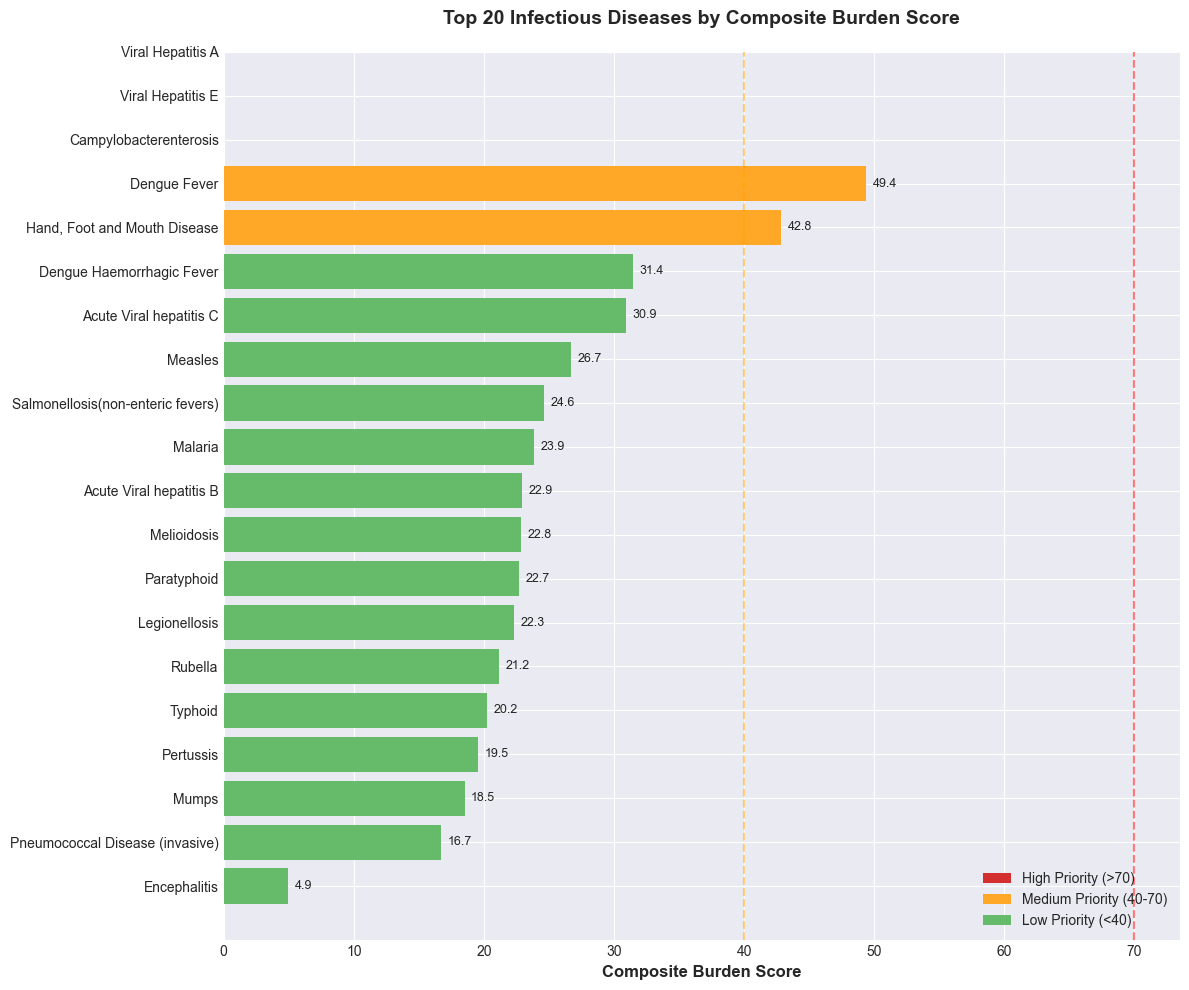

✓ Saved: priority_rankings_bar.png


In [34]:
# Visualization 1: Top 20 Priority Rankings Bar Chart
fig, ax = plt.subplots(figsize=(12, 10))

# Get top 20 (already ranked, so just take first 20 rows and reverse for bar chart display)
top_20 = df_ranked.head(20)

# Extract data to pandas for easier matplotlib compatibility
top_20_pd = top_20.to_pandas().sort_values('composite_score')

# Define tier colors
tier_colors = {'High': '#D32F2F', 'Medium': '#FFA726', 'Low': '#66BB6A'}
colors = [tier_colors[tier] for tier in top_20_pd['tier']]

# Create horizontal bar chart
bars = ax.barh(range(len(top_20_pd)), top_20_pd['composite_score'], color=colors)
ax.set_yticks(range(len(top_20_pd)))
ax.set_yticklabels(top_20_pd['disease_name'])
ax.set_xlabel('Composite Burden Score', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Infectious Diseases by Composite Burden Score', 
             fontsize=14, fontweight='bold', pad=20)

# Add score annotations
for i, (idx, row) in enumerate(top_20_pd.iterrows()):
    ax.text(row['composite_score'] + 0.5, i, f"{row['composite_score']:.1f}", va='center', fontsize=9)

# Add tier threshold lines
ax.axvline(x=70, color='red', linestyle='--', alpha=0.5, label='High Priority Threshold (70)')
ax.axvline(x=40, color='orange', linestyle='--', alpha=0.5, label='Medium Priority Threshold (40)')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=tier_colors['High'], label='High Priority (>70)'),
    Patch(facecolor=tier_colors['Medium'], label='Medium Priority (40-70)'),
    Patch(facecolor=tier_colors['Low'], label='Low Priority (<40)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(figures_dir / 'priority_rankings_bar.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: priority_rankings_bar.png")

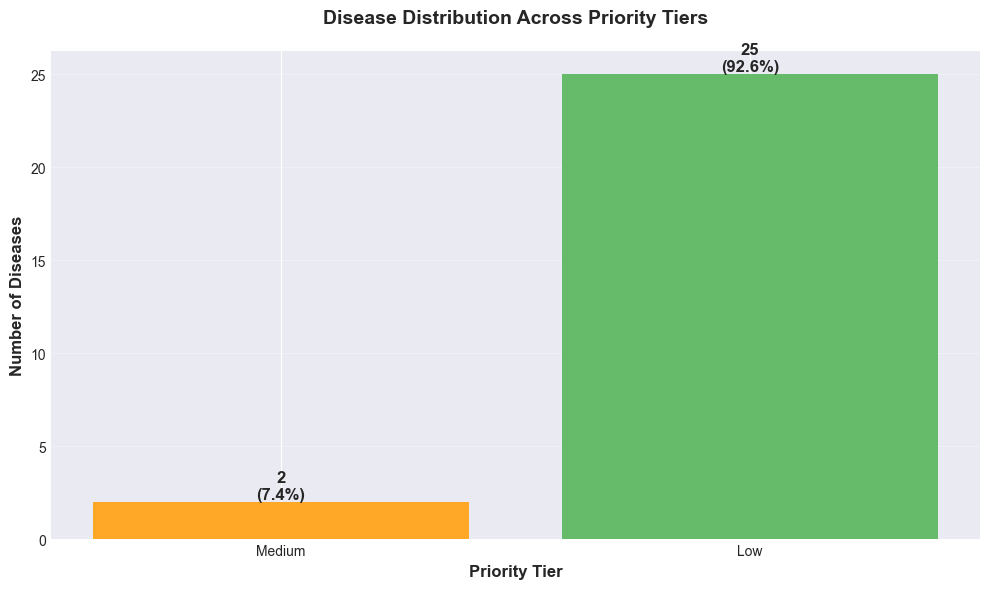

✓ Saved: priority_tiers_distribution.png


In [35]:
# Visualization 2: Tier Distribution
fig, ax = plt.subplots(figsize=(10, 6))

tier_counts = df_ranked.group_by('tier').agg(pl.count().alias('count')).sort('tier', descending=True)
tiers = tier_counts['tier'].to_list()
counts = tier_counts['count'].to_list()
percentages = [(c / len(df_ranked)) * 100 for c in counts]

colors_list = [tier_colors[t] for t in tiers]
bars = ax.bar(tiers, counts, color=colors_list)

# Add count and percentage labels
for bar, count, pct in zip(bars, counts, percentages):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Diseases', fontsize=12, fontweight='bold')
ax.set_xlabel('Priority Tier', fontsize=12, fontweight='bold')
ax.set_title('Disease Distribution Across Priority Tiers', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'priority_tiers_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: priority_tiers_distribution.png")

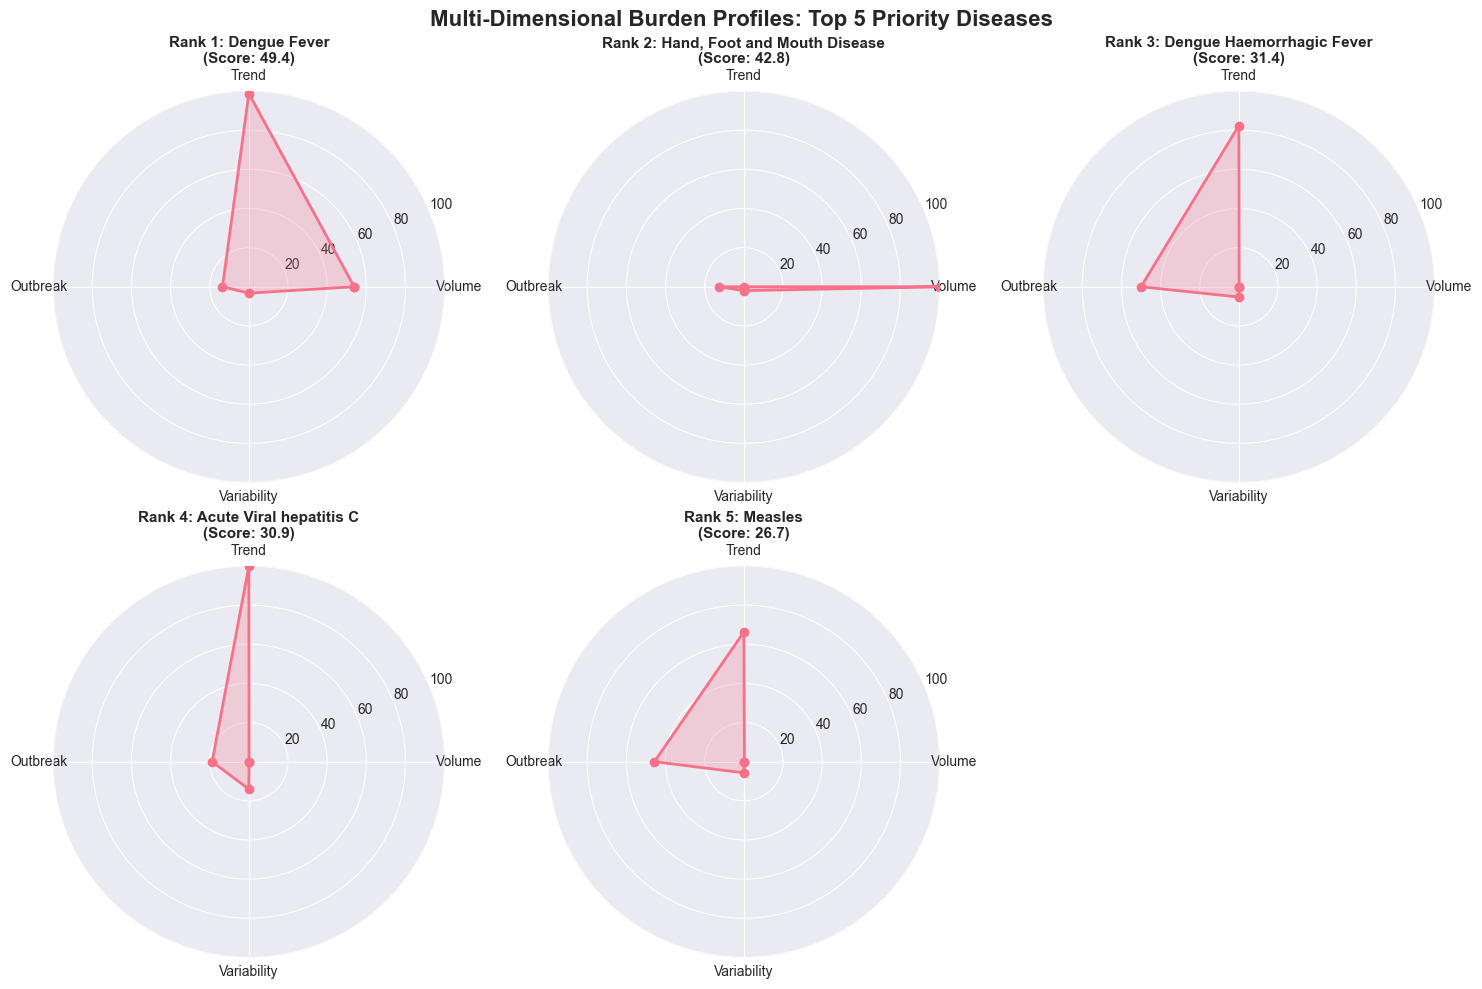

✓ Saved: burden_profiles_radar.png


In [36]:
# Visualization 3: Burden Profiles Radar Charts (Top 5)
from math import pi

fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

# Get top 5 diseases
top_5 = df_ranked.head(5)
categories = ['Volume', 'Trend', 'Outbreak', 'Variability']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

for idx, row in enumerate(top_5.iter_rows(named=True)):
    ax = axes[idx]
    values = [
        row['volume_criterion'],
        row['trend_criterion'],
        row['outbreak_criterion'],
        row['variability_criterion']
    ]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['disease_name'])
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=10)
    ax.set_ylim(0, 100)
    ax.set_title(f"Rank {row['rank']}: {row['disease_name']}\n(Score: {row['composite_score']:.1f})",
                 size=11, fontweight='bold', pad=20)
    ax.grid(True)

# Hide the 6th subplot
axes[5].axis('off')

fig.suptitle('Multi-Dimensional Burden Profiles: Top 5 Priority Diseases', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(figures_dir / 'burden_profiles_radar.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: burden_profiles_radar.png")

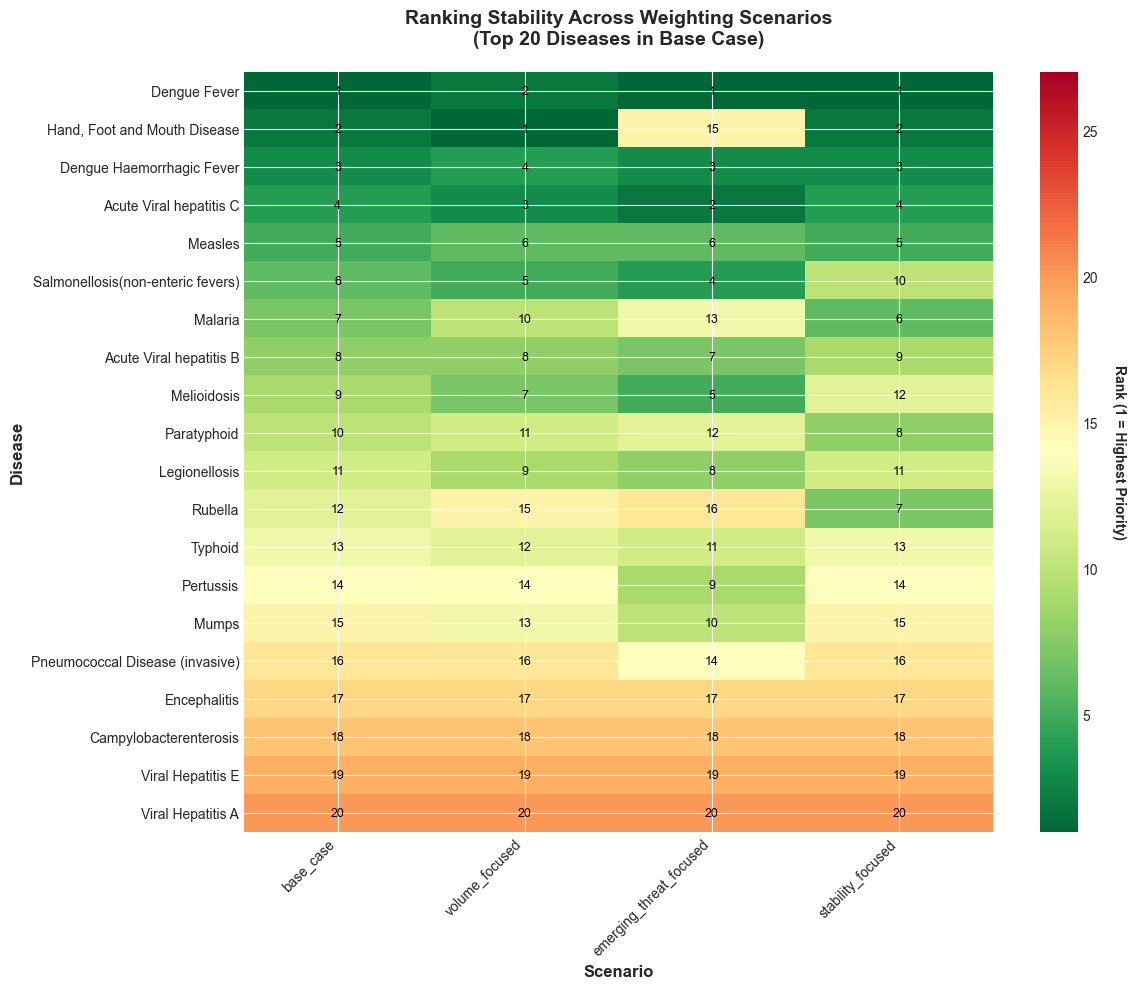

✓ Saved: sensitivity_heatmap.png


In [37]:
# Visualization 4: Sensitivity Analysis Heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Prepare data for heatmap (Top 20 diseases × scenarios)
base_top_20_diseases = df_ranked.head(20)['disease_name'].to_list()

# Create rank matrix
rank_matrix = []
scenario_names = list(rankings.keys())

for disease in base_top_20_diseases:
    disease_ranks = []
    for scenario in scenario_names:
        rank_row = rankings[scenario].filter(pl.col('disease_name') == disease)
        if len(rank_row) > 0:
            disease_ranks.append(rank_row['rank'][0])
        else:
            disease_ranks.append(None)
    rank_matrix.append(disease_ranks)

# Create heatmap
im = ax.imshow(rank_matrix, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=len(df_ranked))

# Set ticks and labels
ax.set_xticks(range(len(scenario_names)))
ax.set_yticks(range(len(base_top_20_diseases)))
ax.set_xticklabels(scenario_names, rotation=45, ha='right')
ax.set_yticklabels(base_top_20_diseases)

# Add rank annotations
for i in range(len(base_top_20_diseases)):
    for j in range(len(scenario_names)):
        if rank_matrix[i][j] is not None:
            text = ax.text(j, i, int(rank_matrix[i][j]),
                          ha="center", va="center", color="black", fontsize=9)

ax.set_title('Ranking Stability Across Weighting Scenarios\n(Top 20 Diseases in Base Case)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Scenario', fontsize=12, fontweight='bold')
ax.set_ylabel('Disease', fontsize=12, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Rank (1 = Highest Priority)', rotation=270, labelpad=20, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / 'sensitivity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: sensitivity_heatmap.png")

## 7. Results Export <a id='export'></a>

Export prioritization results and sensitivity analysis for stakeholder review.

In [38]:
# Create output directory
tables_dir = Path('../../results/tables')
tables_dir.mkdir(parents=True, exist_ok=True)

# Export base case rankings
output_path = tables_dir / 'disease_priority_rankings.csv'
df_ranked.write_csv(output_path)
logger.info(f"Exported rankings to {output_path}")
print(f"✓ Saved: disease_priority_rankings.csv ({len(df_ranked)} diseases)")

2026-02-12 10:41:25,072 - __main__ - INFO - Exported rankings to ../../results/tables/disease_priority_rankings.csv
✓ Saved: disease_priority_rankings.csv (27 diseases)


In [39]:
# Prepare sensitivity analysis results
sensitivity_data = []

for scenario_name, df_scenario in rankings.items():
    for row in df_scenario.iter_rows(named=True):
        sensitivity_data.append({
            'scenario': scenario_name,
            'disease_name': row['disease_name'],
            'rank': row['rank'],
            'composite_score': row['composite_score'],
            'tier': row['tier']
        })

df_sensitivity = pl.DataFrame(sensitivity_data)
sensitivity_path = tables_dir / 'sensitivity_analysis.csv'
df_sensitivity.write_csv(sensitivity_path)
logger.info(f"Exported sensitivity analysis to {sensitivity_path}")
print(f"✓ Saved: sensitivity_analysis.csv ({len(df_sensitivity)} records)")

2026-02-12 10:41:34,215 - __main__ - INFO - Exported sensitivity analysis to ../../results/tables/sensitivity_analysis.csv
✓ Saved: sensitivity_analysis.csv (108 records)


In [40]:
# Export correlation matrix
corr_path = tables_dir / 'rank_correlations.csv'
corr_matrix.write_csv(corr_path)
logger.info(f"Exported correlation matrix to {corr_path}")
print(f"✓ Saved: rank_correlations.csv")

2026-02-12 10:42:02,963 - __main__ - INFO - Exported correlation matrix to ../../results/tables/rank_correlations.csv
✓ Saved: rank_correlations.csv


## 8. Summary & Insights <a id='summary'></a>

Key findings from the prioritization analysis.

In [41]:
print("="*80)
print("DISEASE PRIORITIZATION FRAMEWORK - SUMMARY")
print("="*80)

print(f"\nAnalysis Date: {datetime.now().strftime('%Y-%m-%d')}")
print(f"Total Diseases Analyzed: {len(df_ranked)}")
print(f"Weighting Scheme: Volume {base_weights['volume']*100:.0f}%, Trend {base_weights['trend']*100:.0f}%, Outbreak {base_weights['outbreak']*100:.0f}%, Variability {base_weights['variability']*100:.0f}%")

print("\n" + "="*80)
print("TOP 10 PRIORITY DISEASES")
print("="*80)

for row in df_ranked.head(10).iter_rows(named=True):
    print(f"\n{row['rank']}. {row['disease_name']}")
    print(f"   Composite Score: {row['composite_score']:.2f} | Tier: {row['tier']}")
    print(f"   Volume: {row['volume_criterion']:.1f} | Trend: {row['trend_criterion']:.1f} | "
          f"Outbreak: {row['outbreak_criterion']:.1f} | Variability: {row['variability_criterion']:.1f}")

print("\n" + "="*80)
print("TIER DISTRIBUTION")
print("="*80)

for row in tier_dist.iter_rows(named=True):
    pct = (row['count'] / len(df_ranked)) * 100
    print(f"{row['tier']:8s}: {row['count']:2d} diseases ({pct:5.1f}%)")

print("\n" + "="*80)
print("SENSITIVITY ANALYSIS")
print("="*80)

print(f"\nScenarios Tested: {len(rankings)}")
print(f"Consensus Top 10: {len(consensus_top10)} diseases")

if consensus_top10:
    print("\nDiseases in Top 10 across ALL scenarios:")
    for disease in consensus_top10:
        print(f"  - {disease}")
else:
    print("\nNo diseases consistently in Top 10 across all scenarios.")
    print("Rankings show moderate sensitivity to weighting scheme.")

print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

high_priority = df_ranked.filter(pl.col('tier') == 'High')
if len(high_priority) > 0:
    print(f"\n1. HIGH PRIORITY ({len(high_priority)} diseases): Allocate substantial resources")
    for row in high_priority.head(5).iter_rows(named=True):
        print(f"   - {row['disease_name']}")
else:
    print("\n1. HIGH PRIORITY: No diseases exceed High Priority threshold (>70)")
    print("   Consider reviewing threshold settings or investigating data quality.")

medium_priority = df_ranked.filter(pl.col('tier') == 'Medium')
print(f"\n2. MEDIUM PRIORITY ({len(medium_priority)} diseases): Maintain sustained surveillance and intervention")

low_priority = df_ranked.filter(pl.col('tier') == 'Low')
print(f"\n3. LOW PRIORITY ({len(low_priority)} diseases): Basic surveillance, responsive intervention as needed")

print("\n4. FRAMEWORK MAINTENANCE:")
print("   - Update annually with new surveillance data")
print("   - Re-validate weighting scheme every 2-3 years with stakeholders")
print("   - Monitor for emerging threats requiring ad-hoc prioritization")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nOutputs saved to:")
print(f"  - {output_path}")
print(f"  - {sensitivity_path}")
print(f"  - {corr_path}")
print(f"  - {figures_dir}/ (4 visualizations)")
print("\nReady for stakeholder presentation.")

DISEASE PRIORITIZATION FRAMEWORK - SUMMARY

Analysis Date: 2026-02-12
Total Diseases Analyzed: 27
Weighting Scheme: Volume 40%, Trend 25%, Outbreak 20%, Variability 15%

TOP 10 PRIORITY DISEASES

1. Dengue Fever
   Composite Score: 49.39 | Tier: Medium
   Volume: 53.8 | Trend: 98.7 | Outbreak: 13.5 | Variability: 3.3

2. Hand, Foot and Mouth Disease
   Composite Score: 42.85 | Tier: Medium
   Volume: 100.0 | Trend: 0.0 | Outbreak: 12.7 | Variability: 2.0

3. Dengue Haemorrhagic Fever
   Composite Score: 31.44 | Tier: Low
   Volume: 0.2 | Trend: 82.4 | Outbreak: 50.0 | Variability: 5.3

4. Acute Viral hepatitis C
   Composite Score: 30.89 | Tier: Low
   Volume: 0.1 | Trend: 100.0 | Outbreak: 18.8 | Variability: 14.1

5. Measles
   Composite Score: 26.67 | Tier: Low
   Volume: 0.3 | Trend: 66.3 | Outbreak: 45.7 | Variability: 5.7

6. Salmonellosis(non-enteric fevers)
   Composite Score: 24.60 | Tier: Low
   Volume: 7.0 | Trend: 77.2 | Outbreak: 12.5 | Variability: 0.0

7. Malaria
   Comp